<a href="https://colab.research.google.com/github/sanodyaJinadasa/Medical-Cost-Prediction/blob/main/Medical_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
path=kagglehub.dataset_download("mirichoi0218/insurance")
print("Folder path:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Folder path: /kaggle/input/insurance


In [8]:
csv_file_path = os.path.join(path, "insurance.csv")
print("Exact csv path:", csv_file_path)

Exact csv path: /kaggle/input/insurance/insurance.csv


In [9]:
df = pd.read_csv(csv_file_path)
print("First 5 records:", df.head())

First 5 records:    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [10]:
df.shape

(1338, 7)

In [11]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [13]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Age vs Charges: Split by sex and smoker status

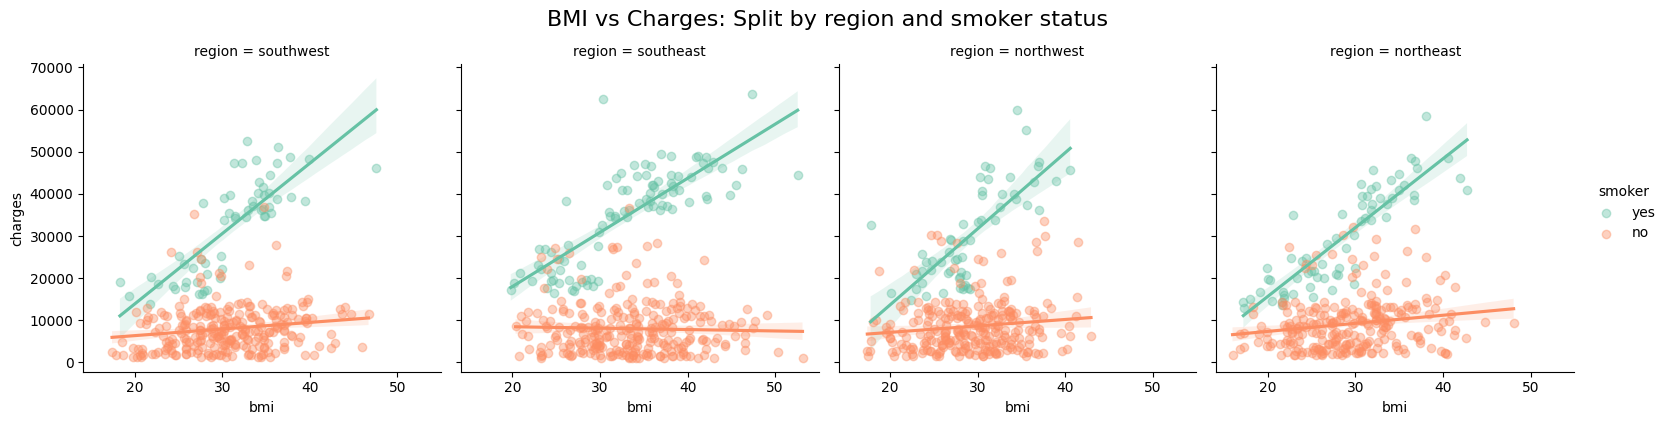

In [24]:
sns.lmplot(x="bmi", y="charges",hue="smoker",col="region",col_wrap=4,height=4,palette="Set2",data=df,scatter_kws={'alpha':0.4})
plt.suptitle("BMI vs Charges: Split by region and smoker status",y=1.05,fontsize=16)
plt.show()

#### Age Penalty

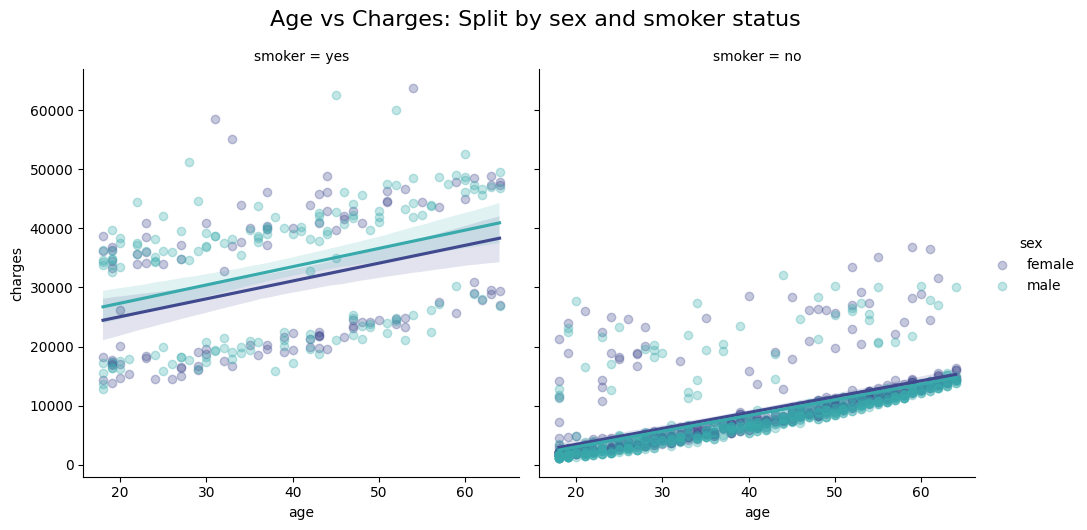

In [29]:
sns.lmplot(x="age", y="charges",hue="sex",col="smoker",col_wrap=2,height=5,palette="mako",data=df,scatter_kws={'alpha':0.3})
plt.suptitle("Age vs Charges: Split by sex and smoker status",y=1.05,fontsize=16)
plt.show()

### Custom Dashboard

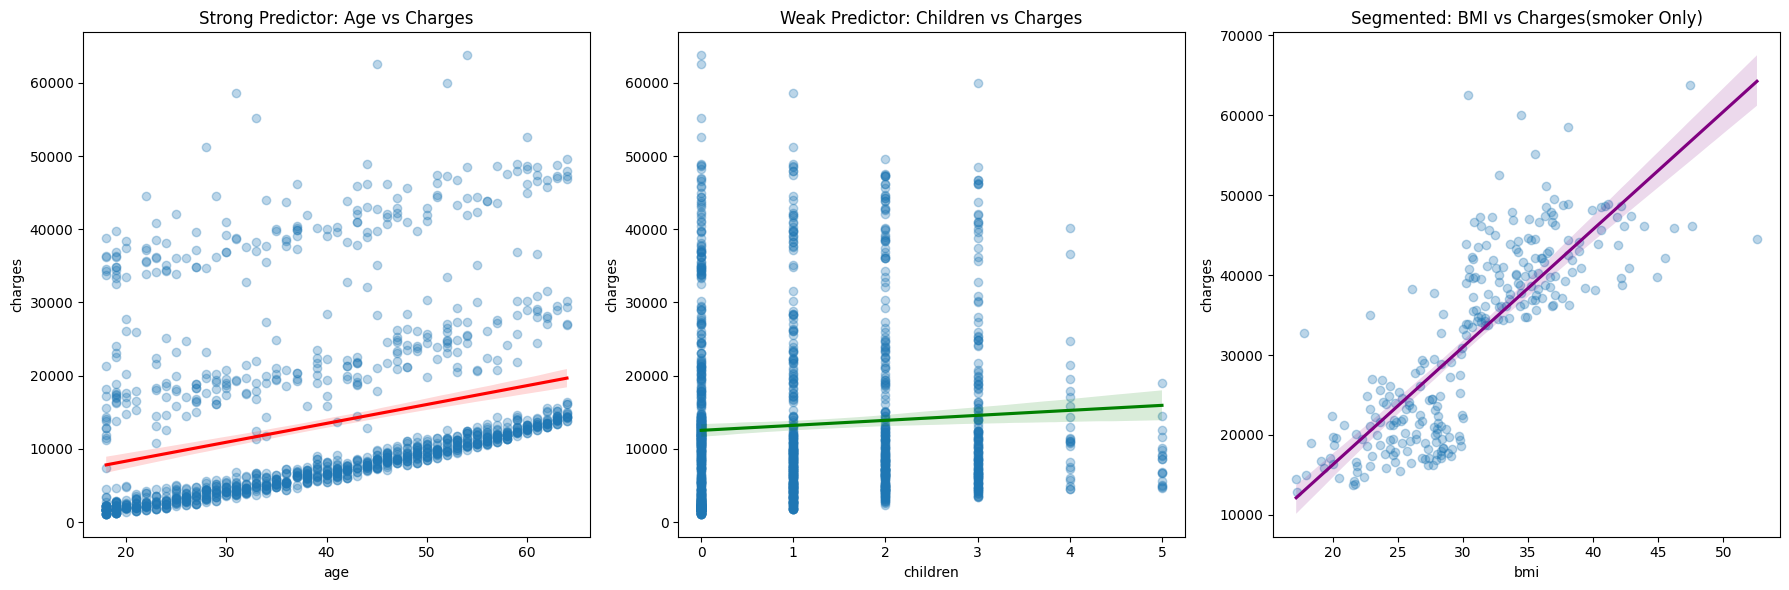

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.regplot(ax=axes[0], x="age", y="charges", data=df, scatter_kws={'alpha':0.3},line_kws={'color':'red'})
axes[0].set_title("Strong Predictor: Age vs Charges")

sns.regplot(ax=axes[1], x="children", y="charges", data=df, scatter_kws={'alpha':0.3},line_kws={'color':'green'})
axes[1].set_title("Weak Predictor: Children vs Charges")

sns.regplot(ax=axes[2], x="bmi", y="charges", data=df[df['smoker']=='yes'] , scatter_kws={'alpha':0.3},line_kws={'color':'purple'})
axes[2].set_title("Segmented: BMI vs Charges(smoker Only)")

plt.tight_layout()
plt.show()

### Pairplot

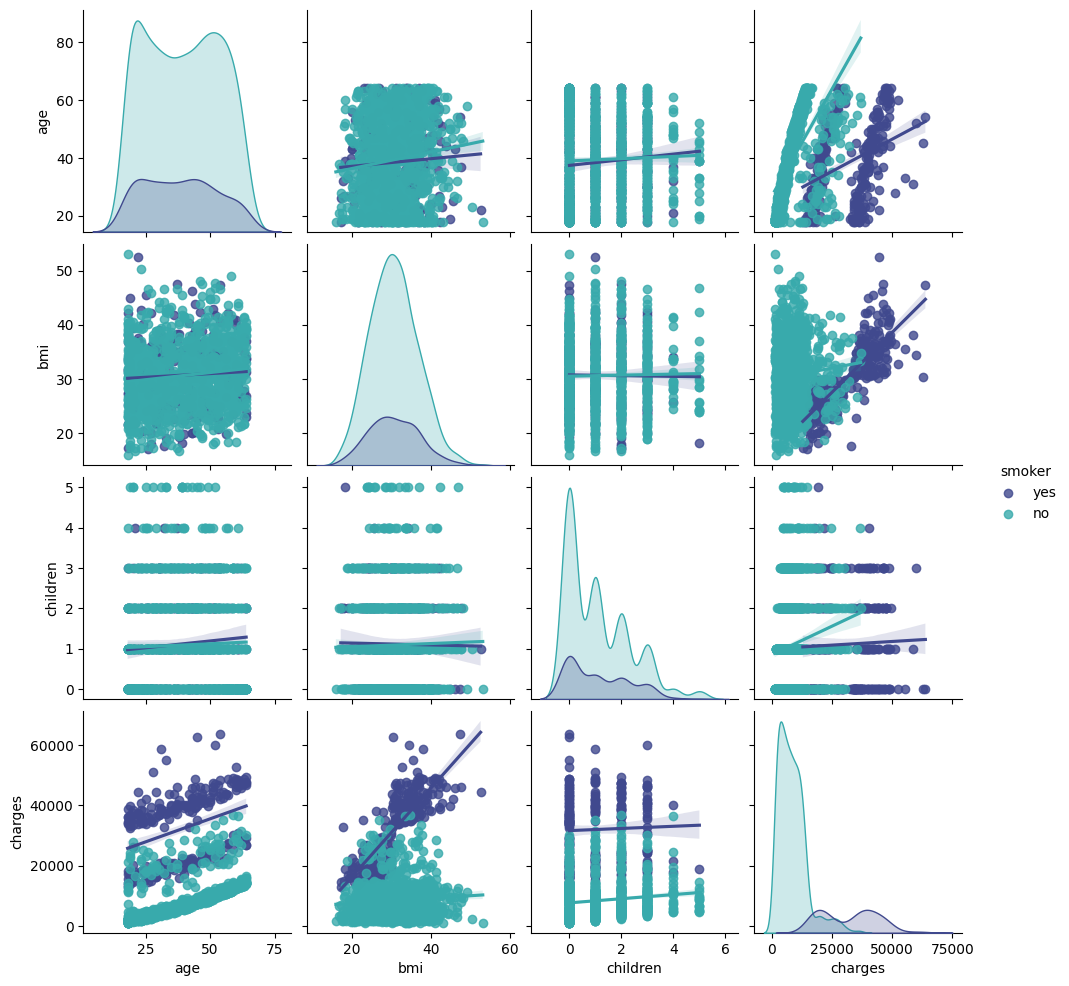

In [34]:
sns.pairplot(df, hue="smoker", palette="mako",kind='reg')
plt.show()

This pair plot illustrates the relationships between age, BMI, number of children, and medical charges, segmented by smoking status. The most striking finding is that smokers (dark purple) consistently incur significantly higher medical charges than non-smokers across all age and BMI categories. While age shows a steady positive correlation with charges for everyone, the combination of smoking and a high BMI leads to the steepest increase in costs, as seen in the clear divergent clusters in the BMI vs. Charges plot. Interestingly, the number of children appears to have a negligible impact on the overall trend of medical expenses compared to the primary lifestyle and biological factors.